<a href="https://colab.research.google.com/github/rocimarquez/.github/blob/main/DQN_reference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reference implementation of Deep Q-Learning

This notebook includes an implementation of the Deep Q-learning algorithm for the Cartpole problem (see [Cartpole documentation](https://gymnasium.farama.org/environments/classic_control/cart_pole/)).


## Libraries

In [ ]:
!pip install gymnasium[classic-control]

import gymnasium as gym
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import time
import random
import math

In [ ]:
!pip install swig
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 44.6 MB/s eta 0:00:00


## Hyperparameters

In [ ]:
# Learning rate
LEARNING_RATE = 0.0005
# Batch size
BATCH_SIZE = 64
# Discount factor gamma
GAMMA = 0.995
# Size of the replay memory (replay buffer) that saves transitions
MEMORY_SIZE = 100000
# Values related to the exploration rate used by the epsilon-greedy policy
EXPLORATION_RATE_MAX = 1
EXPLORATION_RATE_MIN = 0.01
EXPLORATION_RATE_DECAY = 0.997
# Maximum number of episodes for training
MAX_EPISODES_FOR_TRAINING = 1000
# Goal score to be achieved during the training process
TRAINING_GOAL = 200
# Number of episodes used to check the goal score during the training process
EPISODES_TO_CHECK_TRAINING_GOAL = 10
# Number of episodes used to evaluate the model performance after training
EPISODES_TO_EVALUATE_MODEL_PERFORMANCE = 30

## Class ReplayMemory

Memory of transitions for experience replay.

In [ ]:
class ReplayMemory:

    def __init__(self,number_of_observations):
        # Create replay memory

        self.states = np.zeros((MEMORY_SIZE, number_of_observations))
        self.states_next = np.zeros((MEMORY_SIZE, number_of_observations))
        self.actions = np.zeros(MEMORY_SIZE, dtype=np.int32)
        self.rewards = np.zeros(MEMORY_SIZE)
        self.terminal_states = np.zeros(MEMORY_SIZE, dtype=bool)
        self.current_size=0

    def store_transition(self, state, action, reward, state_next, terminal_state):
        # Store a transition (s,a,r,s') in the replay memory
        i = self.current_size
        self.states[i] = state
        self.states_next[i] = state_next
        self.actions[i] = action
        self.rewards[i] = reward
        self.terminal_states[i] = terminal_state
        self.current_size = i + 1

    def sample_memory(self, batch_size):
        # Generate a sample of transitions from the replay memory
        batch = np.random.choice(self.current_size, batch_size)
        states = self.states[batch]
        states_next = self.states_next[batch]
        rewards = self.rewards[batch]
        actions = self.actions[batch]
        terminal_states = self.terminal_states[batch]
        return states, actions, rewards, states_next, terminal_states

## Class DQN

Reinforcement learning agent with a Deep Q-Network.

In [ ]:
class DQN:

    def __init__(self, number_of_observations, number_of_actions):
        # Initialize variables and create neural model

        self.number_of_actions = number_of_actions
        self.number_of_observations = number_of_observations
        self.scores = []
        self.memory = ReplayMemory(number_of_observations)

        # Neural model
        self.model = keras.models.Sequential()
        self.model.add(keras.layers.InputLayer(shape=(number_of_observations,)))
        self.model.add(keras.layers.Dense(128, activation="relu",kernel_initializer="he_normal"))
        self.model.add(keras.layers.Dense(128, activation="relu",kernel_initializer="he_normal"))
        self.model.add(keras.layers.Dense(number_of_actions, activation="linear"))
        self.model.compile(loss="huber", optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE)) #cambiamos loss
        self.target_model = keras.models.clone_model(self.model)
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, terminal_state):
        # Store a tuple (s, a, r, s') for experience replay
        state = np.reshape(state, [1, self.number_of_observations])
        next_state = np.reshape(next_state, [1, self.number_of_observations])
        self.memory.store_transition(state, action, reward, next_state, terminal_state)

    def select_epsilon_greedy_policy(self, state, exploration_rate):
        # Generate an action for a given state using epsilon-greedy policy
        if np.random.rand() < exploration_rate:
            return random.randrange(self.number_of_actions)
        else:
            state = np.reshape(state, [1, self.number_of_observations])
            q_values = self.model(state).numpy()
            return np.argmax(q_values[0])

    def select_greedy_policy(self, state):
        # Generate an action for a given state using greedy policy
        state = np.reshape(state, [1, self.number_of_observations])
        q_values = self.model(state).numpy()
        return np.argmax(q_values[0])

    def learn(self):
        # Learn the value Q using a sample of examples from the replay memory
        if self.memory.current_size < BATCH_SIZE: return

        states, actions, rewards, next_states, terminal_states = self.memory.sample_memory(BATCH_SIZE)

        q_targets = self.model(states).numpy()
        q_next_states = self.target_model(next_states).numpy()

        for i in range(BATCH_SIZE):
             if (terminal_states[i]):
                  q_targets[i][actions[i]] = rewards[i]
             else:
                  q_targets[i][actions[i]] = rewards[i] + GAMMA * np.max(q_next_states[i])

        self.model.train_on_batch(states, q_targets)

        #self.target_model.set_weights(self.model.get_weights())
        if total_steps % 1000 == 0:
            agent.target_model.set_weights(agent.model.get_weights())

    def add_score(self, score):
        # Add the obtained score to a list to be presented later
        self.scores.append(score)

    def delete_scores(self):
        # Delete the scores
        self.scores = []

    def average_score(self, number_of_episodes):
        # Compute average score of the last episodes
        index = len(agent.scores) - number_of_episodes
        return np.mean(self.scores[max(0,index):(len(agent.scores))])

    def display_scores_graphically(self):
        # Display the obtained scores graphically
        plt.plot(self.scores)
        plt.xlabel("Episode")
        plt.ylabel("Score")

    def save_model(self):
        # Save model in format .keras
        self.model.save('my_model.keras')

## Auxiliary function

In [ ]:
def print_time(time):
    min = round(time // 60)
    sec = round(time % 60)
    if min > 0:
        print(f"{min} min {sec} seconds")
    else:
        print(f"{sec} seconds")

## Environment

In [ ]:
def create_environment():
    # Create simulated environment
    environment = gym.make("LunarLander-v3")
    number_of_observations = environment.observation_space.shape[0]
    number_of_actions = environment.action_space.n
    return environment, number_of_observations, number_of_actions

## Program for training

Resumen de Primera modificación realizadas para adaptar la implementación de CartPole al entorno LunarLander-v3 y alcanzar el objetivo de rendimiento (puntuación media > 200), se han realizado las siguientes mejoras técnicas:
1. Implementación de Target NetworkProblema: En el código original, el cálculo de los valores Q objetivo utilizaba la misma red que se estaba entrenando, lo que generaba una gran inestabilidad en LunarLander. Se añadió una Target Network (target_model), que es una copia de la red principal utilizada exclusivamente para predecir los valores Q del siguiente estado.

Gemini dijo
Para tu entrega, es fundamental que el Notebook incluya una sección de texto que justifique claramente los cambios realizados respecto a la implementación de referencia. Aquí tienes un resumen estructurado y profesional que puedes copiar y adaptar en la sección de "Justificación de cambios" de tu trabajo:

Resumen de Modificaciones Realizadas
Para adaptar la implementación de referencia de CartPole al entorno LunarLander-v3 y alcanzar el objetivo de rendimiento (puntuación media > 200), se han realizado las siguientes mejoras técnicas:
+1

1. Implementación de Target Network

Problema: En el código original, el cálculo de los valores Q objetivo utilizaba la misma red que se estaba entrenando, lo que generaba una gran inestabilidad en LunarLander.


Solución: Se añadió una Target Network (target_model), que es una copia de la red principal utilizada exclusivamente para predecir los valores Q del siguiente estado.

Sincronización: Los pesos se sincronizan de la red principal a la de destino cada 1,000 pasos de entrenamiento para estabilizar las señales de aprendizaje.

2. Ajuste de Arquitectura y Pérdida

Función de Pérdida (Huber Loss): Se sustituyó el Error Cuadrático Medio (mse) por la pérdida Huber. Esta es más robusta frente a valores atípicos, como las penalizaciones severas por colisión, evitando cambios bruscos y destructivos en los pesos de la red.

Aumento de capas neuronales: LunarLander tiene 8 variables de observación (posición, velocidad, ángulo, etc.) frente a las 4 de CartPole. Una red de 32 neuronas es pequeña para aprender. Al usar 128 neuronas, permitimos que el modelo identifique mejores patrones

4. Optimización de Hiperparámetros: Factor de Descuento ($\gamma$): Ajustado a 0.995 para dar mayor importancia a las recompensas a largo plazo.

Exploración ($\epsilon$-greedy): Se modificó el EXPLORATION_RATE_DECAY a 0.997 para ralentizar la reducción de la exploración.
Se aumentó el número de episodios máximos para permitir la convergencia en un entorno con dinámicas físicas más complejas que el problema del poste.


In [ ]:
environment, number_of_observations, number_of_actions = create_environment()
agent = DQN(int(number_of_observations), int(number_of_actions))
episode = 0
start_time = time.perf_counter()
total_steps = 0
exploration_rate = EXPLORATION_RATE_MAX
goal_reached = False
while (episode < MAX_EPISODES_FOR_TRAINING) and not(goal_reached):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_epsilon_greedy_policy(state, exploration_rate)

        # Execute the action on the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        total_steps += 1

        # Store in memory the transition (s,a,r,s')
        agent.remember(state, action, reward, state_next, terminal_state)

        score += reward

        # Learn using a batch of experience stored in memory
        agent.learn()

        # Detect end of episode
        if terminal_state or truncated:
            end_episode = True
            agent.add_score(score)
            average_score = agent.average_score(EPISODES_TO_CHECK_TRAINING_GOAL)
            if average_score >= TRAINING_GOAL: goal_reached = True
            print("Episode {0:>3}: ".format(episode), end = '')
            print("score {0:>3} ".format(math.trunc(score)), end = '')
            print("(exploration rate: %.3f, " % exploration_rate, end = '')
            print("average score: {0:>3}, ".format(round(average_score)), end = '')
            print("transitions: " + str(agent.memory.current_size) + ")")
        else:
            state = state_next

    # Decrease exploration rate
    exploration_rate *= EXPLORATION_RATE_DECAY
    exploration_rate = max(EXPLORATION_RATE_MIN, exploration_rate)

print("Time for training: ", end = '')
print_time(time.perf_counter() - start_time)
print("Total steps: ", total_steps)
print("Score (average last episodes):", round(average_score))
print("Score (max):", round(max(agent.scores)))

agent.display_scores_graphically()

agent.save_model()

Episode   1: score -338 (exploration rate: 1.000, average score: -339, transitions: 99)
Episode   2: score  16 (exploration rate: 0.997, average score: -161, transitions: 198)
Episode   3: score -379 (exploration rate: 0.994, average score: -234, transitions: 288)
Episode   4: score -151 (exploration rate: 0.991, average score: -213, transitions: 372)
Episode   5: score -21 (exploration rate: 0.988, average score: -175, transitions: 465)
Episode   6: score -105 (exploration rate: 0.985, average score: -163, transitions: 598)
Episode   7: score -113 (exploration rate: 0.982, average score: -156, transitions: 698)
Episode   8: score -198 (exploration rate: 0.979, average score: -162, transitions: 803)
Episode   9: score -127 (exploration rate: 0.976, average score: -158, transitions: 914)
Episode  10: score -344 (exploration rate: 0.973, average score: -176, transitions: 1060)
Episode  11: score -244 (exploration rate: 0.970, average score: -167, transitions: 1181)
Episode  12: score -17

IndexError: index 100000 is out of bounds for axis 0 with size 100000

el error que aparece se debe a que la memoria dlagente ha llegado a su límite de capacidad. Al intentar guardar la transición número 100,001 (índice 100,000), el programa falla porque el array tiene un tamaño fijo de 100,000.Para solucionar esto modificaremos el método store_transition dentro de la clase ReplayMemory.


## Testing program



In [ ]:
episode = 0
score_list = []
while (episode < EPISODES_TO_EVALUATE_MODEL_PERFORMANCE):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_greedy_policy(state)

        # Execute the action in the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        score += reward
        state = state_next
        end_episode = terminal_state or truncated

    score_list.append(score)
    print("Episode {0:>3}: ".format(episode), end = '')
    print("score {0:>3} \n".format(round(score)), end = '')

print("Score (average):", round(np.mean(score_list)))

Episode   1: score 255 
Episode   2: score 284 
Episode   3: score 278 
Episode   4: score 255 
Episode   5: score 268 
Episode   6: score 303 
Episode   7: score 254 
Episode   8: score 266 
Episode   9: score 282 
Episode  10: score 278 
Episode  11: score 244 
Episode  12: score 266 
Episode  13: score 137 
Episode  14: score 252 
Episode  15: score 263 
Episode  16: score 285 
Episode  17: score 313 
Episode  18: score 255 
Episode  19: score 271 
Episode  20: score 247 
Episode  21: score 277 
Episode  22: score 279 
Episode  23: score 277 
Episode  24: score 273 
Episode  25: score 269 
Episode  26: score 288 
Episode  27: score 252 
Episode  28: score 271 
Episode  29: score 233 
Episode  30: score 257 
Score (average): 264


Como vemos un buen rendimiento, volveremos a una capacidad de 400 episodios máximo, y en esta ocasión aumentaremos el numero de neuronas, bajaremos el EXPLORATION_RATE_DECAY y además haremos el arreglo de la memoria para no obtener el error anterior.

Cambios:


In [ ]:
# Learning rate
LEARNING_RATE = 0.0005
# Batch size
BATCH_SIZE = 64
# Discount factor gamma
GAMMA = 0.995
# Size of the replay memory (replay buffer) that saves transitions
MEMORY_SIZE = 100000
# Values related to the exploration rate used by the epsilon-greedy policy
EXPLORATION_RATE_MAX = 1
EXPLORATION_RATE_MIN = 0.01
EXPLORATION_RATE_DECAY = 0.995
# Maximum number of episodes for training
MAX_EPISODES_FOR_TRAINING = 400
# Goal score to be achieved during the training process
TRAINING_GOAL = 200
# Number of episodes used to check the goal score during the training process
EPISODES_TO_CHECK_TRAINING_GOAL = 10
# Number of episodes used to evaluate the model performance after training
EPISODES_TO_EVALUATE_MODEL_PERFORMANCE = 30

In [ ]:
class ReplayMemory:

    def __init__(self,number_of_observations):
        # Create replay memory

        self.states = np.zeros((MEMORY_SIZE, number_of_observations))
        self.states_next = np.zeros((MEMORY_SIZE, number_of_observations))
        self.actions = np.zeros(MEMORY_SIZE, dtype=np.int32)
        self.rewards = np.zeros(MEMORY_SIZE)
        self.terminal_states = np.zeros(MEMORY_SIZE, dtype=bool)
        self.current_size=0

    def store_transition(self, state, action, reward, state_next, terminal_state):
        # Store a transition (s,a,r,s') in the replay memory
        #i = self.current_size
        i = self.current_size % MEMORY_SIZE
        self.states[i] = state
        self.states_next[i] = state_next
        self.actions[i] = action
        self.rewards[i] = reward
        self.terminal_states[i] = terminal_state
        self.current_size = i + 1

    def sample_memory(self, batch_size):
        # Generate a sample of transitions from the replay memory
        max_mem = min(self.current_size, MEMORY_SIZE)
        batch = np.random.choice(max_mem, batch_size) #aquí cambiamos self.current_size por max_mem
        states = self.states[batch]
        states_next = self.states_next[batch]
        rewards = self.rewards[batch]
        actions = self.actions[batch]
        terminal_states = self.terminal_states[batch]
        return states, actions, rewards, states_next, terminal_states

Episode   1: score -397 (exploration rate: 1.000, average score: -398, transitions: 88)
Episode   2: score -18 (exploration rate: 0.995, average score: -208, transitions: 159)
Episode   3: score -172 (exploration rate: 0.990, average score: -196, transitions: 233)
Episode   4: score -101 (exploration rate: 0.985, average score: -173, transitions: 299)
Episode   5: score -265 (exploration rate: 0.980, average score: -191, transitions: 409)
Episode   6: score -178 (exploration rate: 0.975, average score: -189, transitions: 537)
Episode   7: score -232 (exploration rate: 0.970, average score: -195, transitions: 642)
Episode   8: score -110 (exploration rate: 0.966, average score: -185, transitions: 736)
Episode   9: score -161 (exploration rate: 0.961, average score: -182, transitions: 819)
Episode  10: score -143 (exploration rate: 0.956, average score: -178, transitions: 952)
Episode  11: score -126 (exploration rate: 0.951, average score: -151, transitions: 1030)
Episode  12: score -12

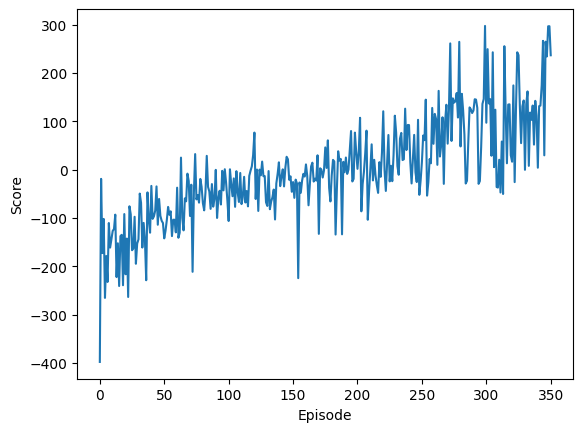

In [ ]:
environment, number_of_observations, number_of_actions = create_environment()
agent = DQN(int(number_of_observations), int(number_of_actions))
episode = 0
start_time = time.perf_counter()
total_steps = 0
exploration_rate = EXPLORATION_RATE_MAX
goal_reached = False
while (episode < MAX_EPISODES_FOR_TRAINING) and not(goal_reached):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_epsilon_greedy_policy(state, exploration_rate)

        # Execute the action on the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        total_steps += 1

        # Store in memory the transition (s,a,r,s')
        agent.remember(state, action, reward, state_next, terminal_state)

        score += reward

        # Learn using a batch of experience stored in memory
        agent.learn()

        # Detect end of episode
        if terminal_state or truncated:
            end_episode = True
            agent.add_score(score)
            average_score = agent.average_score(EPISODES_TO_CHECK_TRAINING_GOAL)
            if average_score >= TRAINING_GOAL: goal_reached = True
            print("Episode {0:>3}: ".format(episode), end = '')
            print("score {0:>3} ".format(math.trunc(score)), end = '')
            print("(exploration rate: %.3f, " % exploration_rate, end = '')
            print("average score: {0:>3}, ".format(round(average_score)), end = '')
            print("transitions: " + str(agent.memory.current_size) + ")")
        else:
            state = state_next

    # Decrease exploration rate
    exploration_rate *= EXPLORATION_RATE_DECAY
    exploration_rate = max(EXPLORATION_RATE_MIN, exploration_rate)

print("Time for training: ", end = '')
print_time(time.perf_counter() - start_time)
print("Total steps: ", total_steps)
print("Score (average last episodes):", round(average_score))
print("Score (max):", round(max(agent.scores)))

agent.display_scores_graphically()

agent.save_model()

In [ ]:
episode = 0
score_list = []
while (episode < EPISODES_TO_EVALUATE_MODEL_PERFORMANCE):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_greedy_policy(state)

        # Execute the action in the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        score += reward
        state = state_next
        end_episode = terminal_state or truncated

    score_list.append(score)
    print("Episode {0:>3}: ".format(episode), end = '')
    print("score {0:>3} \n".format(round(score)), end = '')

print("Score (average):", round(np.mean(score_list)))

Episode   1: score 249 
Episode   2: score 239 
Episode   3: score 269 
Episode   4: score 257 
Episode   5: score 181 
Episode   6: score -109 
Episode   7: score 259 
Episode   8: score 145 
Episode   9: score 295 
Episode  10: score 263 
Episode  11: score 248 
Episode  12: score 255 
Episode  13: score -142 
Episode  14: score 261 
Episode  15: score 250 
Episode  16: score 262 
Episode  17: score 275 
Episode  18: score 277 
Episode  19: score 238 
Episode  20: score 237 
Episode  21: score 262 
Episode  22: score 272 
Episode  23: score 261 
Episode  24: score 290 
Episode  25: score 154 
Episode  26: score 279 
Episode  27: score 280 
Episode  28: score 251 
Episode  29: score 277 
Episode  30: score 264 
Score (average): 227
